# Axis-independence pressure-test (pilot, read-only)

Are the two proposed axes independent on the 90 pilot concepts?
- **axis (ii) compositional-rank** = band-averaged `λ1/trace` (low = composite). *Paper's existing spine.*
- **axis (i) abstraction-depth** = where the top-1 direction "locks in" (consecutive-layer |cos| ≥ 0.8); alt proxy = `magn`-onset depth.

If a depth proxy and `λ1/trace` are strongly correlated (or the depth proxy has no variance), the 2-axis story collapses.
**Caveat:** both depth proxies are *reading* (extraction-geometry), not steering — read≠write. A faithful "first steerable layer" needs per-layer steering sweeps (out of scope here).

In [1]:
import pickle, glob, os, numpy as np, torch, pandas as pd
from scipy.stats import spearmanr

LLM = "llama_3_8b_it_eng_only"
classfiles = {'places':'data/places/places.txt','moods':'data/moods/moods.txt','personalities':'data/personalities/personalities.txt'}
name2class = {}
for cls, fn in classfiles.items():
    for line in open(fn, encoding='utf-8'):
        s = line.strip()
        if s: name2class[s.lower()] = cls

def concept_of(path):
    b = os.path.splitext(os.path.basename(path))[0]
    if b.endswith('_rfmstats'): b = b[:-len('_rfmstats')]
    if b.endswith('_'+LLM):     b = b[:-len('_'+LLM)]
    if b.startswith('rfm_'):    b = b[len('rfm_'):]
    return b

key  = lambda depth: depth - 32
BAND = list(range(4, 25))   # decoder depths 4..24

In [2]:
rows = []
for sf in sorted(glob.glob('directions/*_rfmstats.pkl')):
    concept = concept_of(sf); cls = name2class.get(concept.lower())
    if cls is None: continue
    d = pickle.load(open(sf, 'rb'))
    frac1 = np.mean([d[key(z)]['frac1'] for z in BAND])          # axis ii
    pr    = np.mean([d[key(z)]['pr']    for z in BAND])
    magn  = np.array([d[key(z)]['magn'] for z in range(1, 32)])
    onset = next((z for z in range(1,32) if magn[z-1] >= 0.25*magn.max()), 31)   # axis i alt
    U = pickle.load(open(sf.replace('_rfmstats',''), 'rb'))       # eigenvectors (3,4096)
    cos = np.array([torch.abs(torch.dot(U[key(z)][0], U[key(z+1)][0]) /
                    (U[key(z)][0].norm()*U[key(z+1)][0].norm())).item() for z in range(1,31)])
    stab = next((z for z in range(1,31) if cos[z-1] >= 0.8), 31)  # axis i primary
    rows.append(dict(concept=concept, cls=cls, frac1=frac1, pr=pr, stab=stab, onset=onset))

df = pd.DataFrame(rows)
print("n matched:", len(df), "| by class:", df['cls'].value_counts().to_dict())
print("\nstabilization-depth spread (axis i):", df['stab'].describe()[['min','50%','max','std']].to_dict())
df.groupby('cls')[['frac1','pr','stab','onset']].median()

n matched: 90 | by class: {'places': 30, 'personalities': 30, 'moods': 30}

stabilization-depth spread (axis i): {'min': 16.0, '50%': 18.0, 'max': 18.0, 'std': 0.5192907868894986}


,frac1,pr,stab,onset
cls,,,,
moods,0.553530,2.575704,17.0,27.0
personalities,0.592933,2.457593,18.0,29.0
places,0.628424,2.274146,18.0,29.0


In [3]:
print("=== INDEPENDENCE: axis-i (depth) vs axis-ii (frac1) — Spearman rho ===")
for ip, nm in [('stab','stabiliz-depth'), ('onset','magn-onset')]:
    r,p = spearmanr(df[ip], df['frac1'])
    print(f"  POOLED {nm:>14} vs frac1: rho={r:+.3f} p={p:.2g}")
    for cls in ['moods','places','personalities']:
        s = df[df['cls']==cls]; r,p = spearmanr(s[ip], s['frac1'])
        print(f"     {cls:>13} (n={len(s)}): rho={r:+.3f} p={p:.2g}")

=== INDEPENDENCE: axis-i (depth) vs axis-ii (frac1) — Spearman rho ===
  POOLED stabiliz-depth vs frac1: rho=+0.163 p=0.13
             moods (n=30): rho=-0.470 p=0.0088
            places (n=30): rho=-0.419 p=0.021
     personalities (n=30): rho=-0.058 p=0.76
  POOLED     magn-onset vs frac1: rho=+0.259 p=0.014
             moods (n=30): rho=-0.238 p=0.21
            places (n=30): rho=+0.579 p=0.0008
     personalities (n=30): rho=+0.362 p=0.05


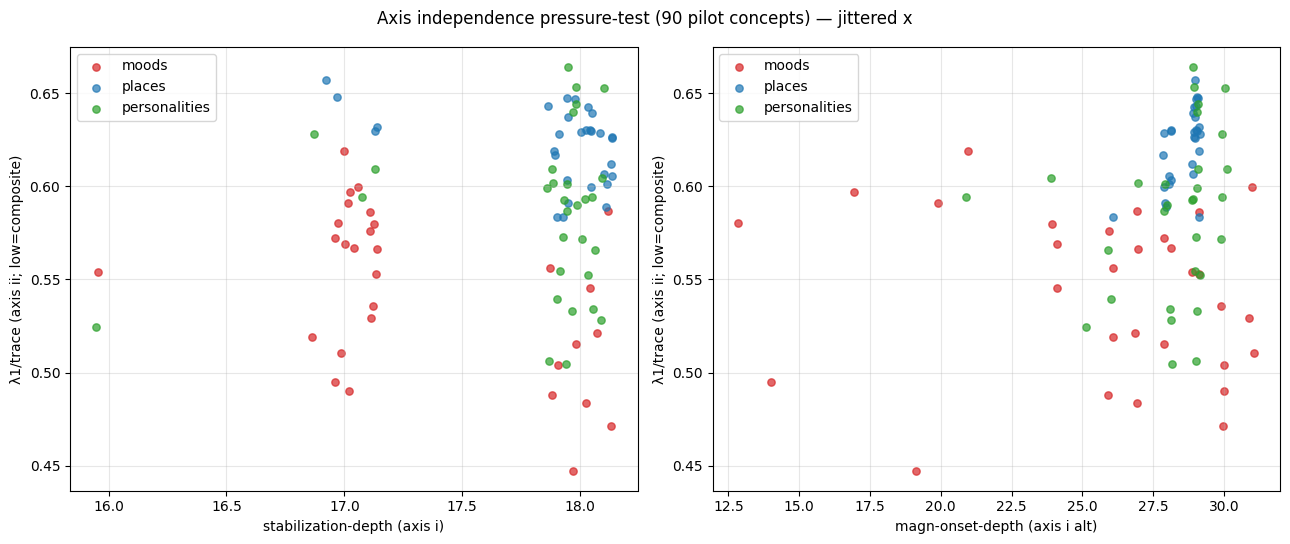

In [4]:
import matplotlib.pyplot as plt
colors = {'moods':'tab:red','places':'tab:blue','personalities':'tab:green'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax,(xc,xl) in zip(axes, [('stab','stabilization-depth (axis i)'), ('onset','magn-onset-depth (axis i alt)')]):
    for cls,c in colors.items():
        s = df[df['cls']==cls]
        ax.scatter(s[xc] + np.random.uniform(-0.15,0.15,len(s)), s['frac1'], c=c, label=cls, alpha=0.7, s=28)
    ax.set_xlabel(xl); ax.set_ylabel('λ1/trace (axis ii; low=composite)'); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle('Axis independence pressure-test (90 pilot concepts) — jittered x'); fig.tight_layout()
fig.savefig('plots/axes_independence.png', dpi=130, bbox_inches='tight'); plt.show()

## Verdict

**The cheap depth proxy has no variance.** Stabilization-depth is 16–18 for *all 90 concepts* (std ≈ 0.5): the lock-in depth is a **model-structural constant**, not a concept property — every concept's top-1 direction settles at ~17–18 regardless of class. So as a candidate *independent* second axis it carries almost no per-concept signal; the within-class "correlations" are over a 2–3-value range and not meaningful.

**axis (ii) behaves as predicted:** moods lowest `λ1/trace` (most composite) → places highest (most atomic) — clean, matches the concreteness story.

**The alternate proxy (`magn`-onset) is unreliable:** large range but late (depth 27–29, the next-token/output zone) and its correlation with `λ1/trace` flips sign across classes — confounded, not a clean abstraction signal.

**Conclusion:** extraction-geometry *reading* proxies do **not** establish abstraction-depth as a usable independent dimension on the pilot. The likely reason: "when the direction stabilizes" measures *assembly timing* (model-constant), not *abstraction-hierarchy position* (parent-vs-child content), which is what axis (i) actually means. Settling it needs either WordNet **taxonomic-depth** as ground truth, or faithful **per-layer steering** (what content each depth produces) — not a cheap proxy. Pressure-test outcome: **do not build the 2-axis paper on reading proxies.**